# CBAM ResNet18 Architecture

This model builds upon the ResNet18 model by implementing a Convolutional Block Attention Module (CBAM), which gives both SE-like channel reweighting and spatial focus, with minimal cost.

Essentially the benefits of Squeeze-Excitation (SE) with channel-wise importance, and Spatial Self-Attention with global dependencies, but without the high cost.

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights


In [2]:
import refactor.src.data as data
import refactor.src.models as models
import refactor.src.trainer as trainer
import refactor.src.evaluator as evaluator

## Data Acquisition & Processing

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


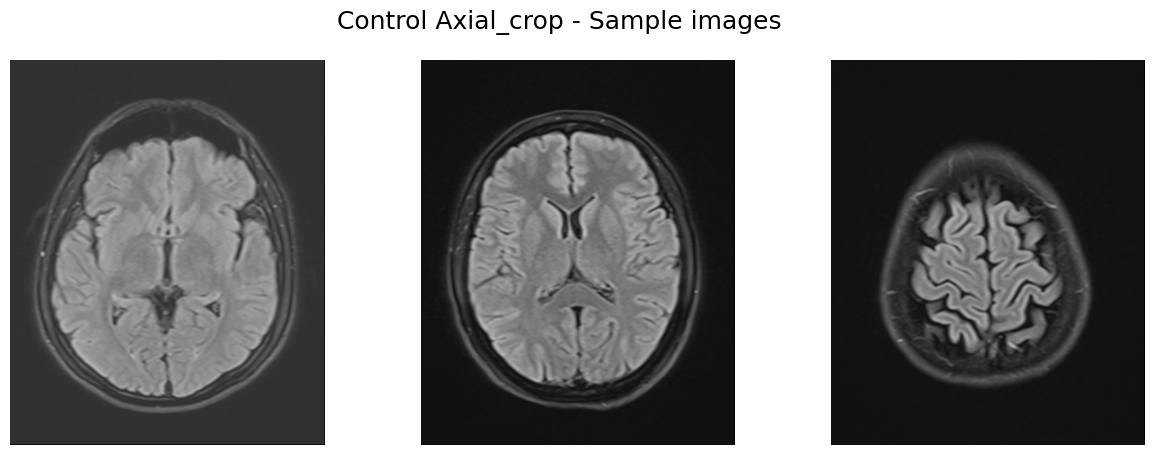

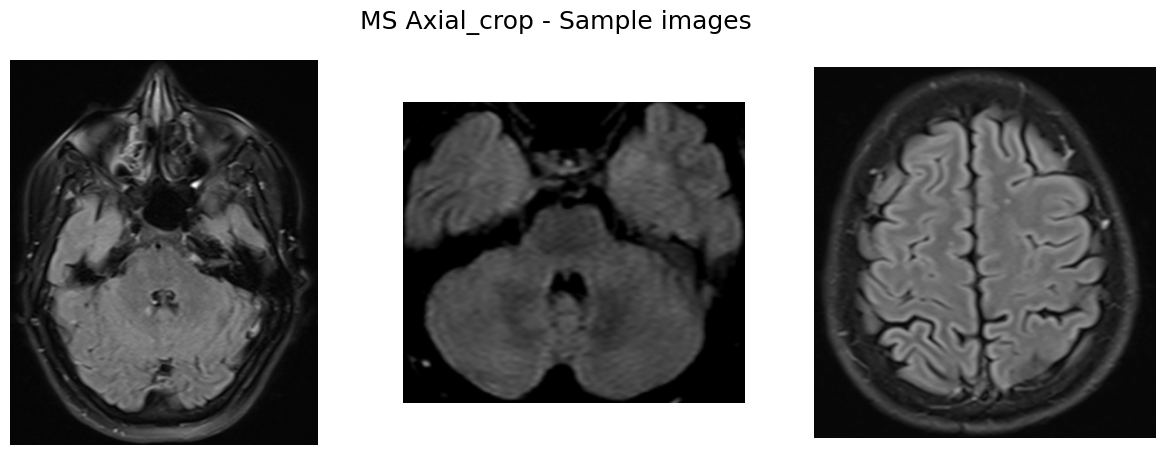

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Training samples: 1321, Testing samples: 331


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

train_loader, test_loader, test_data = data.get_data_loaders(image_paths, labels, train_transform, test_transform)

## Model Instantiation

There are several different CBAM model variations relating to different CBAM placement options. These options are as follows:
- **architecture = "cbam_end"** : Single CBAM before the classifier (after layer 4)
- **architecture = "cbam_block_pre"**: CBAM built into each BasicBlock (before the shortcut)
- **architecture = "cbam_block_post"**: CBAM built into each BasicBlock (after the shortcut)

In [4]:
# Using simplest CBAM model variation with a single CBAM module at the end of ResNet18 before classification
model = models.get_model(architecture="cbam_end")

get_model()>>> architecture='cbam_end'  head='mlp'


## Model Training

**Loss (BCEWithLogitsLoss)**: Binary cross-entropy loss combined with a sigmoid on logits. 
- Measures how well predicted probabilities match true binary labels
- Lower is better.<br>

**Loss & Acc**: Training metrics averaged over an epoch: Loss is mean training loss, Acc is training accuracy for that epoch.<br>

In [5]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head_and_attention",
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,
        "parameters": "all",
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}


=== Phase 1: head_and_attention mode ===
TRAINABLE parameters:
  ✓ avgpool.0.ca.fc.0.weight
  ✓ avgpool.0.ca.fc.2.weight
  ✓ avgpool.0.sa.conv.weight
  ✓ fc.0.weight
  ✓ fc.0.bias
  ✓ fc.3.weight
  ✓ fc.3.bias

FROZEN parameters:
  ✗ conv1.weight
  ✗ bn1.weight
  ✗ bn1.bias
  ✗ layer1.0.conv1.weight
  ✗ layer1.0.bn1.weight
  ✗ layer1.0.bn1.bias
  ✗ layer1.0.conv2.weight
  ✗ layer1.0.bn2.weight
  ✗ layer1.0.bn2.bias
  ✗ layer1.1.conv1.weight
  ✗ layer1.1.bn1.weight
  ✗ layer1.1.bn1.bias
  ✗ layer1.1.conv2.weight
  ✗ layer1.1.bn2.weight
  ✗ layer1.1.bn2.bias
  ✗ layer2.0.conv1.weight
  ✗ layer2.0.bn1.weight
  ✗ layer2.0.bn1.bias
  ✗ layer2.0.conv2.weight
  ✗ layer2.0.bn2.weight
  ✗ layer2.0.bn2.bias
  ✗ layer2.0.downsample.0.weight
  ✗ layer2.0.downsample.1.weight
  ✗ layer2.0.downsample.1.bias
  ✗ layer2.1.conv1.weight
  ✗ layer2.1.bn1.weight
  ✗ layer2.1.bn1.bias
  ✗ layer2.1.conv2.weight
  ✗ layer2.1.bn2.weight
  ✗ layer2.1.bn2.bias
  ✗ layer3.0.conv1.weight
  ✗ layer3.0.bn1.weight
 

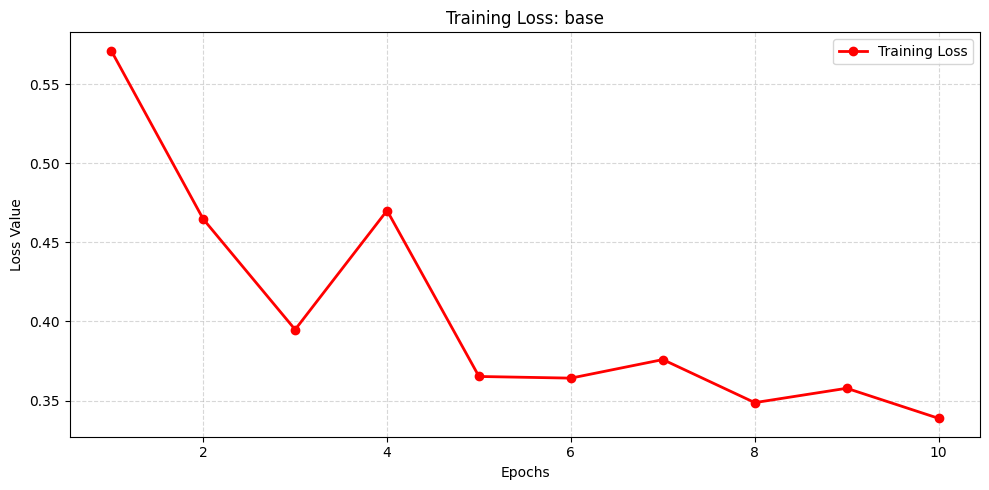

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\cbam_end_basev2.pth


In [6]:
# Base training phase - only training classifier head
# Phase 1 — verify attention is training
train_losses, train_accuracies = trainer.train_model(
    model, train_loader, 
    config_name="base", 
    train_configs=train_configs,
    verbose=True  # <- prints trainable/frozen params
)
trainer.plot(train_losses, train_accuracies, config_name="base")

trainer.save_weights(model, WEIGHTS_DIR / "cbam_end_basev2.pth")


[fine_tune] Epoch 1/5 - Loss: 0.3210 - Acc: 0.8653
[fine_tune] Epoch 2/5 - Loss: 0.2354 - Acc: 0.9092
[fine_tune] Epoch 3/5 - Loss: 0.2111 - Acc: 0.9198
[fine_tune] Epoch 4/5 - Loss: 0.1845 - Acc: 0.9251
[fine_tune] Epoch 5/5 - Loss: 0.1554 - Acc: 0.9470


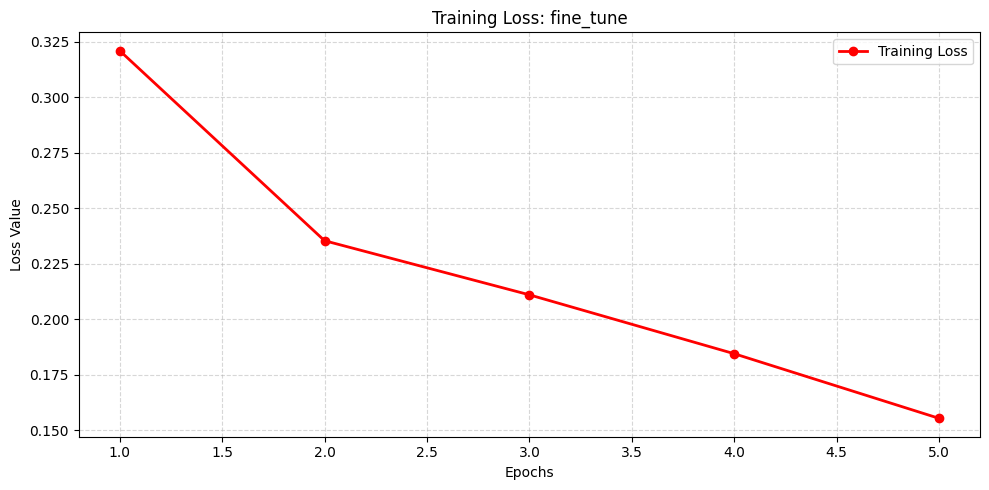

save_weights()>>> Model weights saved to C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\CNNS\weights\cbam_end_finev2.pth


In [7]:
# Fine-tuning phase - training entire model
train_losses, train_accuracies = trainer.train_model(model, train_loader, config_name="fine_tune", train_configs=train_configs)
trainer.plot(train_losses, train_accuracies, config_name="fine_tune")

trainer.save_weights(model, WEIGHTS_DIR / "cbam_end_finev2.pth")


## Load Saved Weights
Option to load weights from previous training

In [8]:
model = models.get_model(architecture="cbam_end")
model = trainer.load_weights(model, WEIGHTS_DIR / "cbam_end_finev2.pth")

get_model()>>> architecture='cbam_end'  head='mlp'
load_weights()>>> Model loaded successfully and set to evaluation mode.


## Model Evaluation
**Accuracy**: Proportion of all predictions that are correct. 
- (TP + TN) / (TP + TN + FP + FN). 
- Good overall when classes are balanced.<br>

**Precision**: Of all examples predicted positive, the fraction that are actually positive. 
- TP / (TP + FP). 
- Measures false positive rate impact.<br>

**Recall (sensitivity)**: Of all actual positive examples, the fraction the model found. 
- TP / (TP + FN). 
- Measures false negative rate impact.<br>

**F1-score**: Harmonic mean of precision and recall: 
- 2 * (precision * recall) / (precision + recall). 
- Balances precision and recall.<br>

**Confusion_matrix**: 2x2 table for binary classification: 
- [[TN, FP],[FN, TP]] 
- Showing counts of true negatives, false positives, false negatives, true positives.<br>

**Classification_report**: Summary table per class containing precision, recall, f1-score and support (number of true instances for each class). 
- Also shows macro/weighted averages.<br>

In [9]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\refactor\src\evaluator.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.9093655589123867
Precision: 0.8731343283582089
Recall: 0.9
Confusion Matrix:
 [[184  17]
 [ 13 117]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92       201
           1       0.87      0.90      0.89       130

    accuracy                           0.91       331
   macro avg       0.90      0.91      0.91       331
weighted avg       0.91      0.91      0.91       331



(0.9093655589123867,
 0.8731343283582089,
 0.9,
 array([[184,  17],
        [ 13, 117]]),
 '              precision    recall  f1-score   support\n\n           0       0.93      0.92      0.92       201\n           1       0.87      0.90      0.89       130\n\n    accuracy                           0.91       331\n   macro avg       0.90      0.91      0.91       331\nweighted avg       0.91      0.91      0.91       331\n')

## Model Prediction Visualisation

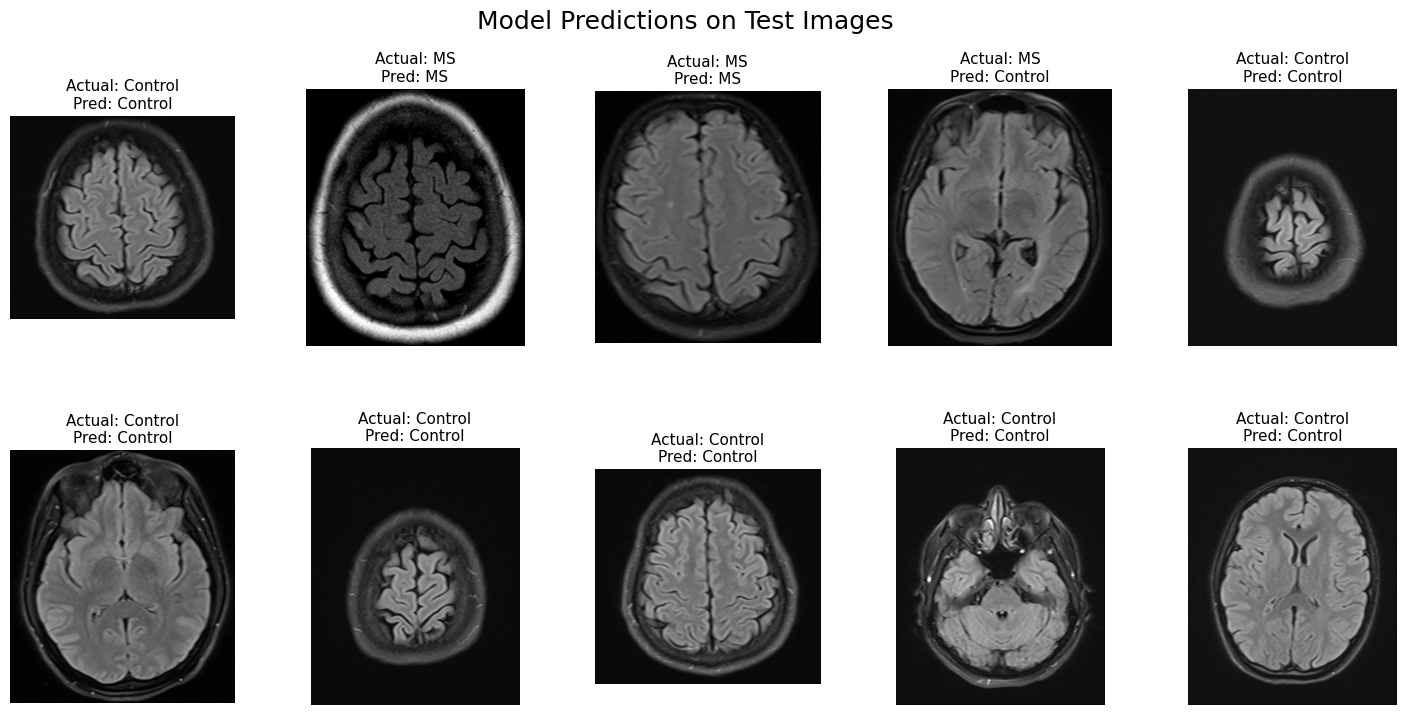

In [10]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)